Saved /scratch/gpfs/GVILLARI/mb6477/Tiger_HLM_Routing/tests/timing_comparison_2021.csv


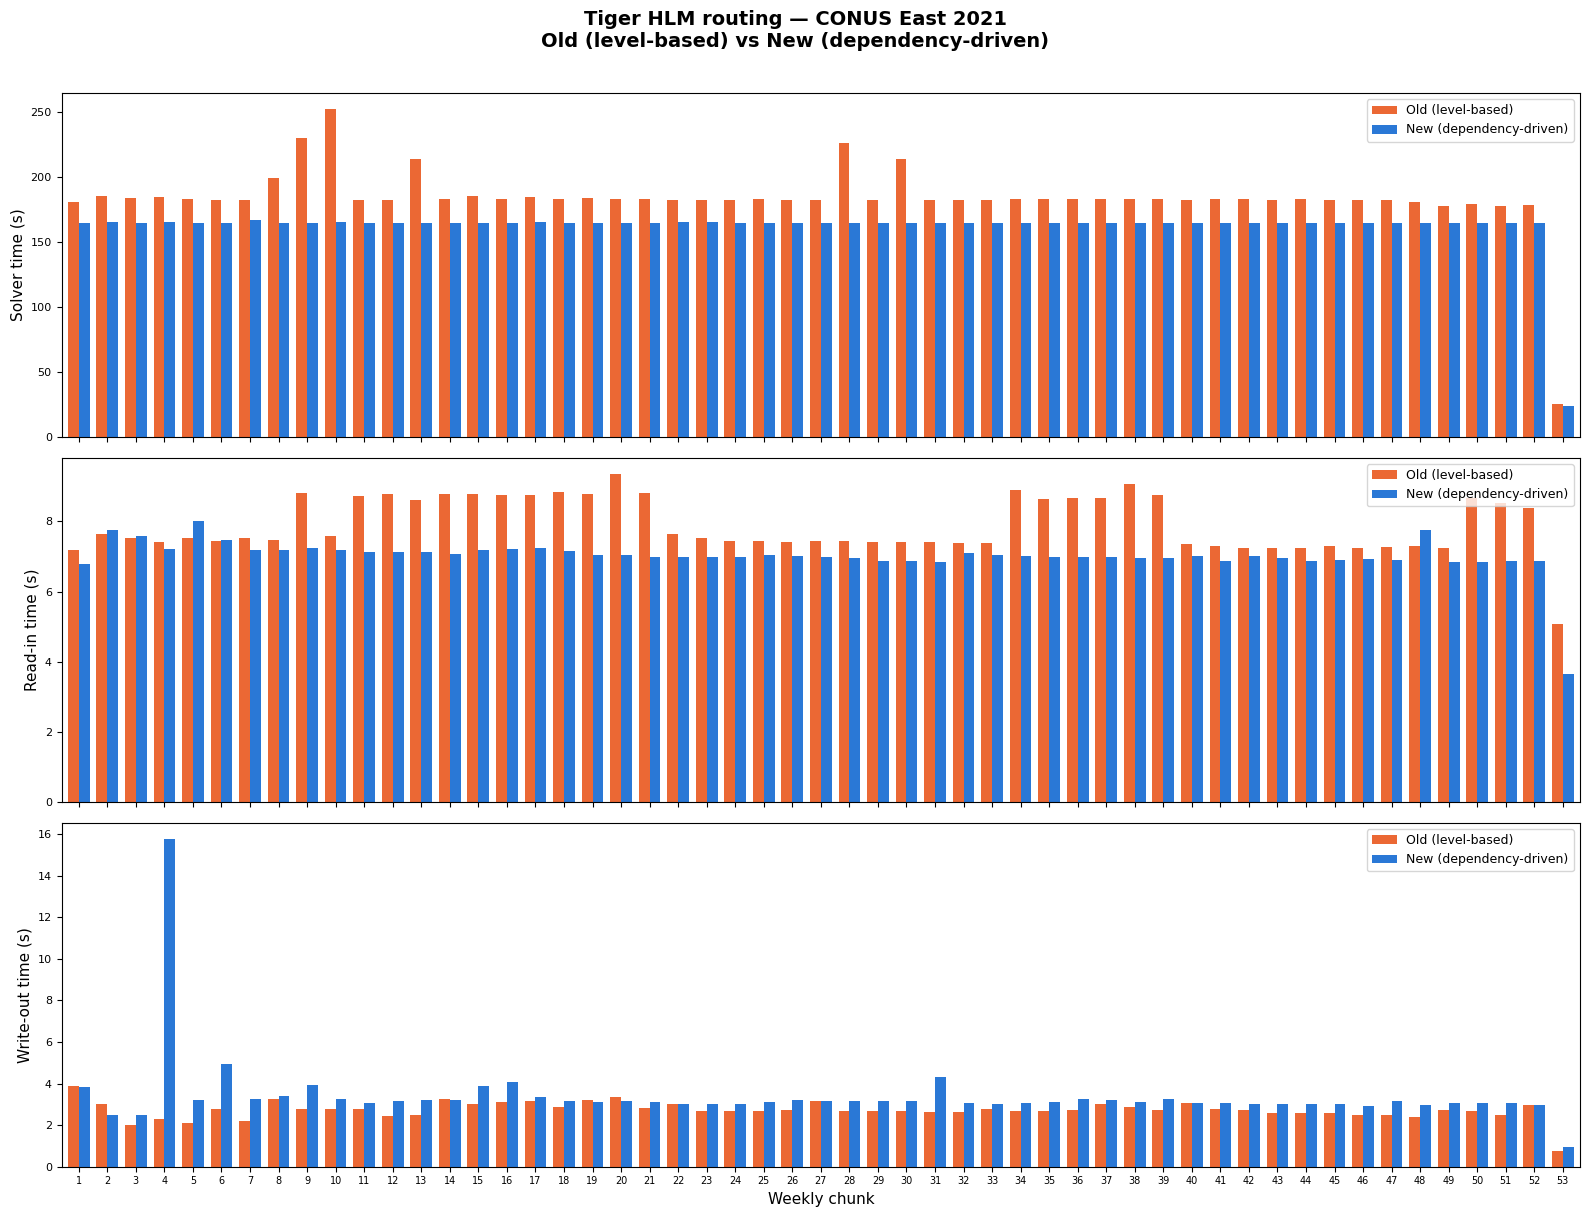

     Solver time (s):  old 9,747s  →  new 8,581s  (Δ +1,166s, +12.0%)
    Read-in time (s):  old 419s  →  new 372s  (Δ +47s, +11.2%)
  Write-out time (s):  old 145s  →  new 181s  (Δ -36s, -25.0%)
---------------------------------------------------------------------------
               Total:  old 10,310s  →  new 9,134s  (Δ +1,176s, +11.4%)


In [4]:
import re
import csv
import matplotlib.pyplot as plt
import numpy as np

# ── paths ──────────────────────────────────────────────────────────────
OLD_LOG = "/scratch/gpfs/GVILLARI/mb6477/Tiger_HLM_Routing/tests/out_2021.txt"
NEW_LOG = "/scratch/gpfs/GVILLARI/mb6477/Tiger_HLM_Routing/tests/log.txt"
CSV_OUT = "/scratch/gpfs/GVILLARI/mb6477/Tiger_HLM_Routing/tests/timing_comparison_2021.csv"

# ── parse ──────────────────────────────────────────────────────────────
def parse_log(filepath):
    with open(filepath) as f:
        text = f.read()
    return {
        "integration": [float(m) for m in re.findall(r"Total integration time:\s+([\d.]+)\s+seconds", text)],
        "read":        [float(m) for m in re.findall(r"Total read in time:\s+([\d.]+)\s+seconds", text)],
        "write":       [float(m) for m in re.findall(r"Total write time:\s+([\d.]+)\s+seconds", text)],
    }

old = parse_log(OLD_LOG)
new = parse_log(NEW_LOG)
n = min(len(old["integration"]), len(new["integration"]))

# ── save csv ───────────────────────────────────────────────────────────
with open(CSV_OUT, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "chunk",
        "old_integration_s", "new_integration_s", "delta_integration_s",
        "old_read_s",        "new_read_s",        "delta_read_s",
        "old_write_s",       "new_write_s",       "delta_write_s",
    ])
    for i in range(n):
        w.writerow([
            i + 1,
            f"{old['integration'][i]:.2f}", f"{new['integration'][i]:.2f}",
            f"{old['integration'][i] - new['integration'][i]:.2f}",
            f"{old['read'][i]:.2f}",        f"{new['read'][i]:.2f}",
            f"{old['read'][i] - new['read'][i]:.2f}",
            f"{old['write'][i]:.2f}",       f"{new['write'][i]:.2f}",
            f"{old['write'][i] - new['write'][i]:.2f}",
        ])
print(f"Saved {CSV_OUT}")

# ── grouped bar charts: old | new paired per chunk ────────────────────
chunks = np.arange(n)
width  = 0.38

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

panels = [
    ("integration", "Solver time (s)"),
    ("read",        "Read-in time (s)"),
    ("write",       "Write-out time (s)"),
]

for ax, (phase, ylabel) in zip(axes, panels):
    ax.bar(chunks - width / 2, old[phase][:n], width,
           label="Old (level-based)", color="#eb6834", edgecolor="none")
    ax.bar(chunks + width / 2, new[phase][:n], width,
           label="New (dependency-driven)", color="#2a78d6", edgecolor="none")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelsize=8)
    ax.set_xlim(-0.6, n - 0.4)

axes[-1].set_xlabel("Weekly chunk", fontsize=11)
axes[-1].set_xticks(chunks)
axes[-1].set_xticklabels([str(i + 1) for i in chunks], fontsize=7)

fig.suptitle("Tiger HLM routing — CONUS East 2021\nOld (level-based) vs New (dependency-driven)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

# ── quick totals ───────────────────────────────────────────────────────
total_old = 0
total_new = 0
for phase, label in panels:
    o, nw = sum(old[phase]), sum(new[phase])
    total_old += o
    total_new += nw
    print(f"{label:>20}:  old {o:,.0f}s  →  new {nw:,.0f}s  (Δ {o - nw:+,.0f}s, {(o - nw) / o * 100:+.1f}%)")
print("-" * 75)
print(f"{'Total':>20}:  old {total_old:,.0f}s  →  new {total_new:,.0f}s  (Δ {total_old - total_new:+,.0f}s, {(total_old - total_new) / total_old * 100:+.1f}%)")